In [44]:
import pandas as pd
import numpy as np
#import re
import ast
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv("movies_dataset.csv")
keep_cols = ["id", "title", "release_date", "budget", "revenue", "genres"]
df = df[keep_cols].copy()




In [46]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

In [47]:
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")

In [48]:
df["genre_list"] = df["genres"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)   

df["main_genre"] = df["genre_list"].apply(
    lambda x: x[0] if len(x) > 0 else np.nan
)


In [49]:
df["profit"] = df["revenue"] - df["budget"]
df["roi"] = np.where(df["budget"] > 0, df["revenue"] / df["budget"], np.nan)

In [50]:
bins = [1989, 1999, 2009, 2019, 2025]
labels = ["1990s", "2000s", "2010s", "2020-2025"]
df["release_period"] = pd.cut(df["release_year"], bins=bins, labels=labels)

In [51]:
df_rq1 = df[

    (df["budget"] > 0) &
    (df["revenue"] > 0)
].copy()

In [52]:
df_rq1.shape

(2373, 12)

In [53]:
movies_per_year = df_rq1.groupby("release_year").size()
movies_per_year.describe()

count    35.000000
mean     67.800000
std      14.748479
min      34.000000
25%      58.000000
50%      69.000000
75%      80.500000
max      93.000000
dtype: float64

In [54]:
df_rq1[["budget", "revenue", "profit", "roi"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

,budget,revenue,profit,roi
count,2.373000e+03,2.373000e+03,2.373000e+03,2373.000000
mean,5.247649e+07,1.784184e+08,1.259419e+08,11.658646
std,5.863897e+07,2.697628e+08,2.304580e+08,278.102133
min,1.000000e+00,1.400000e+01,-2.190078e+08,0.000021
1%,1.000000e+05,2.459968e+04,-5.126877e+07,0.010169
5%,1.800000e+06,6.342608e+05,-2.137153e+07,0.103005
50%,3.000000e+07,7.805314e+07,4.150000e+07,2.506418
95%,1.800000e+08,7.402472e+08,5.804376e+08,13.026489
99%,2.500000e+08,1.249635e+09,1.035646e+09,34.399815
max,4.899000e+08,2.923706e+09,2.686706e+09,12890.386667


In [55]:
df_rq1.sort_values("roi", ascending=False)[["title", "release_year", "budget", "revenue", "roi"]].head(10)
df_rq1.sort_values("profit", ascending=False)[["title", "release_year", "budget", "revenue", "profit"]].head(10)

,title,release_year,budget,revenue,profit
7593,Avatar,2009,237000000.0,2.923706e+09,2.686706e+09
11600,Avengers: Endgame,2019,356000000.0,2.799439e+09,2.443439e+09
2797,Titanic,1997,200000000.0,2.264162e+09,2.064162e+09
12784,Avatar: The Way of Water,2022,350000000.0,2.353096e+09,2.003096e+09
10037,Star Wars: The Force Awakens,2015,245000000.0,2.068224e+09,1.823224e+09
11188,Avengers: Infinity War,2018,300000000.0,2.052415e+09,1.752415e+09
12387,Spider-Man: No Way Home,2021,200000000.0,1.921847e+09,1.721847e+09
9996,Jurassic World,2015,150000000.0,1.671537e+09,1.521537e+09
13591,Inside Out 2,2024,200000000.0,1.698864e+09,1.498864e+09
11905,The Lion King,2019,260000000.0,1.662021e+09,1.402021e+09


In [56]:
df_rq1["log_budget"] = np.log(df_rq1["budget"])
df_rq1["log_revenue"] = np.log(df_rq1["revenue"])

In [57]:
df_rq1[["log_budget", "log_revenue"]].corr()

,log_budget,log_revenue
log_budget,1.000000,0.735736
log_revenue,0.735736,1.000000


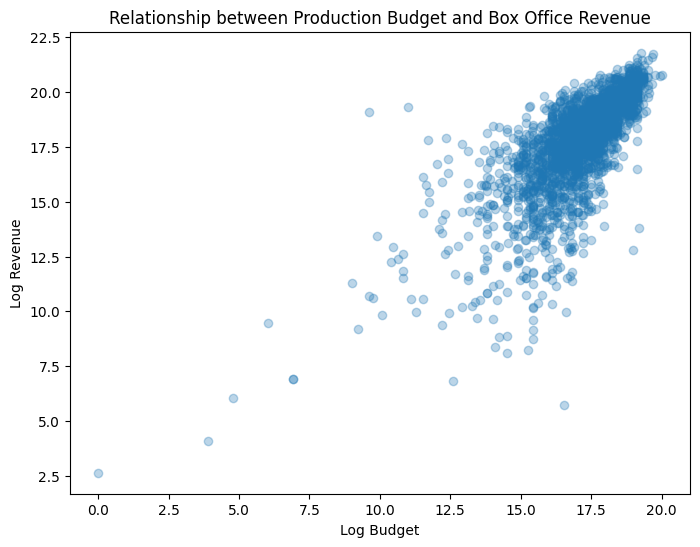

In [58]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_rq1["log_budget"],
    df_rq1["log_revenue"],
    alpha=0.3
)

plt.xlabel("Log Budget")
plt.ylabel("Log Revenue")
plt.title("Relationship between Production Budget and Box Office Revenue")

plt.show()

In [59]:
x = df_rq1["log_budget"].values
y = df_rq1["log_revenue"].values

X = np.column_stack((np.ones(len(x)), x))
beta = np.linalg.lstsq(X, y, rcond=None)[0]

print("Intercept:", beta[0])
print("Budget effect:", beta[1])

Intercept: 0.045063517608703356
Budget effect: 1.0366854926220976


There is a strong positive relationship between production budget and box office revenue.
A 1% increase in production budget is associated with approximately a 1.04% increase in box office revenue.

In [62]:
df_rq1["main_genre"].value_counts().head(10)

main_genre
Action             463
Drama              448
Comedy             387
Adventure          173
Horror             170
Animation          132
Crime              113
Thriller           109
Science Fiction     95
Fantasy             75
Name: count, dtype: int64

In [63]:
genres = ["Action", "Drama", "Comedy", "Adventure", "Horror", "Animation"]

results = []

for g in genres:
    
    df_g = df_rq1[df_rq1["main_genre"] == g]
    
    x = df_g["log_budget"].values
    y = df_g["log_revenue"].values
    
    X = np.column_stack((np.ones(len(x)), x))
    
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    
    results.append({
        "genre": g,
        "n_movies": len(df_g),
        "budget_effect": beta[1]
    })

results_df = pd.DataFrame(results)

results_df

,genre,n_movies,budget_effect
0,Action,463,1.053546
1,Drama,448,0.994714
2,Comedy,387,1.137762
3,Adventure,173,1.202565
4,Horror,170,0.846592
5,Animation,132,1.088332


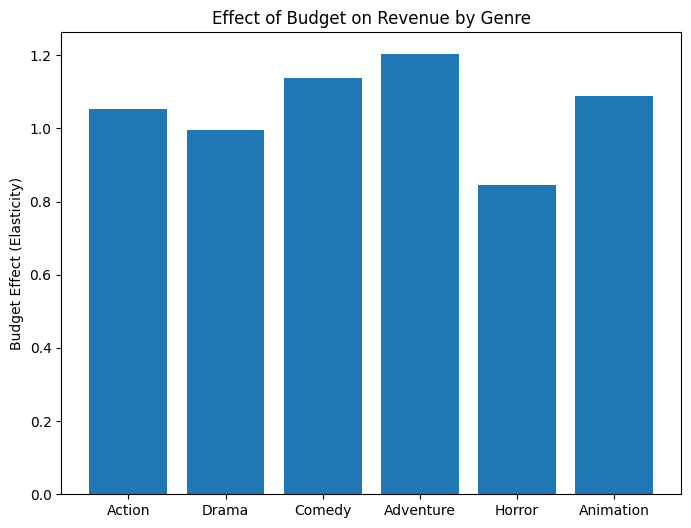

In [64]:
plt.figure(figsize=(8,6))

plt.bar(results_df["genre"], results_df["budget_effect"])

plt.ylabel("Budget Effect (Elasticity)")
plt.title("Effect of Budget on Revenue by Genre")

plt.show()

The analysis shows that the effect of production budget on box office revenue differs across film genres.
While the relationship is strongest for adventure and comedy films, it is noticeably weaker for horror movies, suggesting that high production budgets are less critical for financial success in that genre.

In [65]:
periods = ["1990s", "2000s", "2010s", "2020-2025"]

results_period = []

for p in periods:
    
    df_p = df_rq1[df_rq1["release_period"] == p]
    
    x = df_p["log_budget"].values
    y = df_p["log_revenue"].values
    
    X = np.column_stack((np.ones(len(x)), x))
    
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    
    results_period.append({
        "period": p,
        "n_movies": len(df_p),
        "budget_effect": beta[1]
    })

results_period_df = pd.DataFrame(results_period)

results_period_df

,period,n_movies,budget_effect
0,1990s,542,0.991316
1,2000s,780,0.973214
2,2010s,765,1.153468
3,2020-2025,286,1.028936


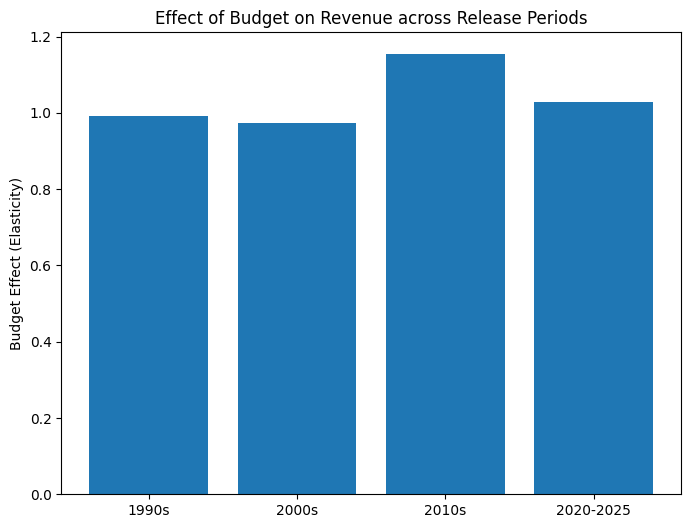

In [66]:
plt.figure(figsize=(8,6))

plt.bar(results_period_df["period"], results_period_df["budget_effect"])

plt.ylabel("Budget Effect (Elasticity)")
plt.title("Effect of Budget on Revenue across Release Periods")

plt.show()

The relationship between production budget and box office revenue varies across time periods. While the effect was close to proportional in the 1990s and 2000s,
it became significantly stronger during the 2010s, suggesting that large production budgets became increasingly important for commercial success during that decade.